<a href="https://colab.research.google.com/github/manan16/PNN_coursework/blob/main/CW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install tensorflow==2.20.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 53.4 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is inc

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Dropout, RandomRotation, BatchNormalization


In [ ]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train.shape, y_train.shape, x_test.shape, y_test.shape


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

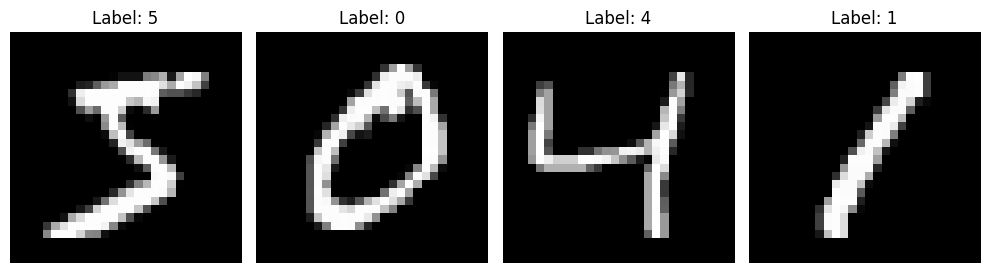

In [ ]:
# Print 4 images in a row
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
shuffle_indices = np.random.permutation(len(x_train))
x_train = x_train[shuffle_indices]
y_train = y_train[shuffle_indices]

x_val = x_train[:10000]
y_val = y_train[:10000]

x_train = x_train[10000:]
y_train = y_train[10000:]

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0


x_train.shape, y_train.shape, x_test.shape, y_test.shape, x_val.shape, y_val.shape


((50000, 28, 28),
 (50000,),
 (10000, 28, 28),
 (10000,),
 (10000, 28, 28),
 (10000,))

In [ ]:
# Build the model
model2 = Sequential([
    Input(shape=(28, 28, 1)),
    RandomRotation(factor=(-0.04,0.04)),
    Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'),
    Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'),
    Dropout(0.25),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'),
    Dropout(0.25),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,418 (3.42 MB)

 Trainable params: 897,162 (3.42 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
# Compile the model
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model2.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_val, y_val))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.9068 - loss: 0.3117 - val_accuracy: 0.9847 - val_loss: 0.0500
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9740 - loss: 0.0827 - val_accuracy: 0.9886 - val_loss: 0.0395
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9790 - loss: 0.0673 - val_accuracy: 0.9856 - val_loss: 0.0487
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9819 - loss: 0.0591 - val_accuracy: 0.9910 - val_loss: 0.0314
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9867 - loss: 0.0455 - val_accuracy: 0.9910 - val_loss: 0.0314
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9881 - loss: 0.0397 - val_accuracy: 0.9885 - val_loss: 0.0368
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9886 - loss: 0.0381 - val_accuracy: 0.9913 - val_loss: 0.0278
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9882 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9930 - loss: 0.0227
Test accuracy: 0.9943000078201294
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted: 7, True: 7
Predicted: 2, True: 2
Predicted: 1, True: 1
Predicted: 0, True: 0
Predicted: 4, True: 4
Predicted: 1, True: 1
Predicted: 4, True: 4
Predicted: 9, True: 9
Predicted: 6, True: 5
Predicted: 9, True: 9


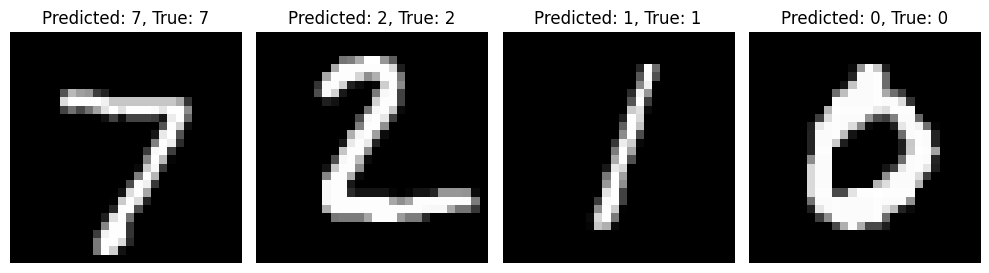

In [ ]:
# Evaluate the model
test_loss, test_acc = model2.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc}")

# Predict the labels for the test set
predictions = model2.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

# Print the first 10 predicted labels and their corresponding true labels
for i in range(10):
    print(f"Predicted: {predicted_labels[i]}, True: {y_test[i]}")
# Print 4 images in a row with their predicted and true labels
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}, True: {y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
model2.save('model2.h5')

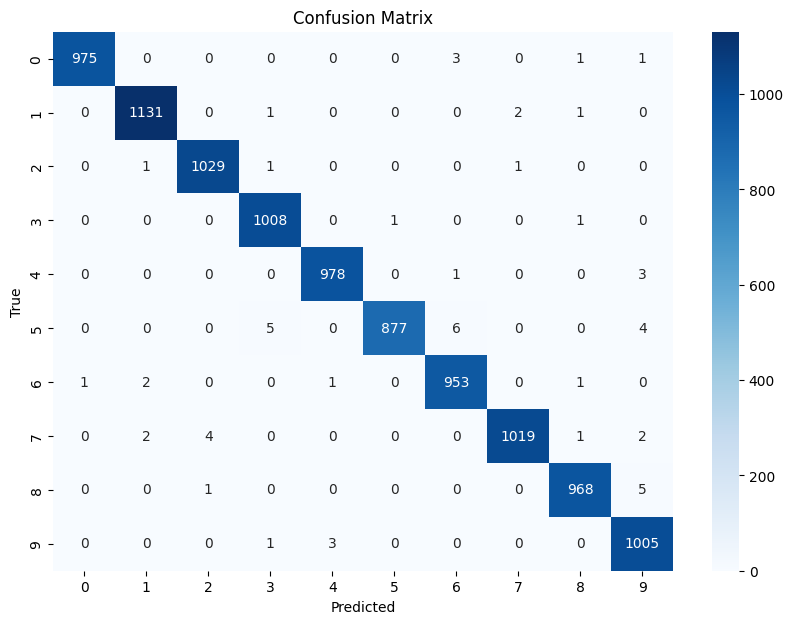

In [ ]:
# confusion matrix

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predicted_labels)

import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


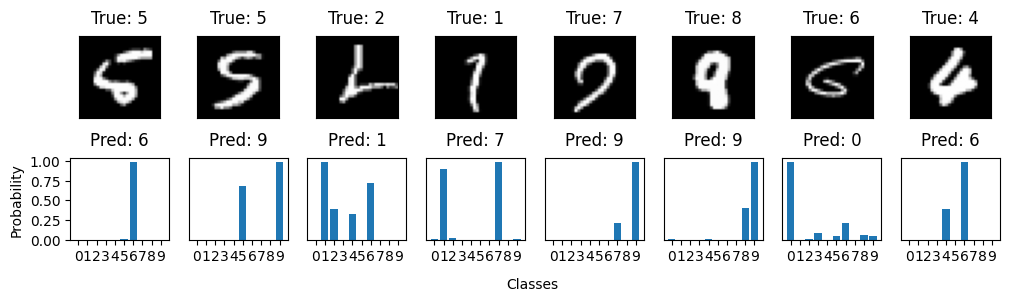

In [ ]:
# Find and plot some misclassified samples
misclassified_indices = np.where(predicted_labels != y_test)[0]
n_plot = min(len(misclassified_indices), 8)
import matplotlib.pyplot as plt
if n_plot > 0:
    fig, axes = plt.subplots(2, n_plot, figsize=(12, 3))
    # Combine and move figure-level adjustments outside the loop
    fig.subplots_adjust(hspace=0.5, bottom=0.2)
    for i in range(n_plot):
        idx = misclassified_indices[i]
        axes[0, i].imshow(x_test[idx], cmap='gray') # x_test[idx] now has shape (28, 28, 1), so no need to reshape here
        axes[0, i].set_title(f'True: {y_test[idx]}', y=1.05)
        axes[0, i].get_xaxis().set_visible(False)
        axes[0, i].get_yaxis().set_visible(False)

        # Now, x_test[idx] is (28, 28, 1), so we only need to add the batch dimension
        output = model2.predict(np.expand_dims(x_test[idx], axis=0))
        output = output[0, 0:]
        axes[1, i].bar(range(10), output)
        axes[1, i].set_xticks(range(10))
        axes[1, i].set_title(f'Pred: {np.argmax(output)}', y=1.05)
        axes[1, i].get_yaxis().set_visible(False)
        if i == 0:
            axes[1, i].get_yaxis().set_visible(True)
            axes[1, 0].set_ylabel('Probability')
            axes[1, 0].set_yticks([0, 0.25, 0.5, 0.75, 1])
    # Move fig.text outside the loop as it's a figure-level element
    fig.text(0.51, 0.05, 'Classes', ha='center', va='center')
    plt.savefig("misclassified.pdf")
    plt.show() # Display the plot
else:
    print("No misclassified samples found. No plot generated.")

In [ ]:
len(misclassified_indices)

57

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np

# Load EMNIST digits
(ds_train_new, ds_test_new), ds_info = tfds.load(
    "emnist/digits",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

# Convert to numpy
def to_numpy(ds):
    X_list, y_list = [], []
    for x, y in tfds.as_numpy(ds):
        X_list.append(x[..., 0])  # remove channel dim
        y_list.append(y)
    return np.array(X_list), np.array(y_list)

X_train_new, y_train_new = to_numpy(ds_train_new)
X_test_new, y_test_new = to_numpy(ds_test_new)

# Normalize (like MNIST)
X_train_new = X_train_new.astype("float32") / 255.0
X_test_new  = X_test_new.astype("float32") / 255.0

# Add channel dimension (for CNN models)
X_train_new = X_train_new[..., np.newaxis]
X_test_new  = X_test_new[..., np.newaxis]

print(X_train_new.shape, y_train_new.shape)
print(X_test_new.shape, y_test_new.shape)

(240000, 28, 28, 1) (240000,)
(40000, 28, 28, 1) (40000,)


In [ ]:
from sklearn.model_selection import train_test_split

# Create validation split (20% of training data)
X_train_new, X_val_new, y_train_new, y_val_new = train_test_split(
    X_train_new,
    y_train_new,
    test_size=0.2,
    random_state=42,
    stratify=y_train_new  # keeps class balance
)

print("Train:", X_train_new.shape, y_train_new.shape)
print("Val:", X_val_new.shape, y_val_new.shape)
print("Test:", X_test_new.shape, y_test_new.shape)

Train: (192000, 28, 28, 1) (192000,)
Val: (48000, 28, 28, 1) (48000,)
Test: (40000, 28, 28, 1) (40000,)


In [ ]:
model2.fit(
    X_train_new,
    y_train_new,
    validation_data=(X_val_new, y_val_new),
    epochs=10,
    batch_size=128
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.9446 - loss: 0.2950 - val_accuracy: 0.9895 - val_loss: 0.0383
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.9888 - loss: 0.0399 - val_accuracy: 0.9933 - val_loss: 0.0251
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9911 - loss: 0.0316 - val_accuracy: 0.9925 - val_loss: 0.0263
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9918 - loss: 0.0292 - val_accuracy: 0.9939 - val_loss: 0.0224
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9934 - loss: 0.0235 - val_accuracy: 0.9950 - val_loss: 0.0178
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9934 - loss: 0.0234 - val_accuracy: 0.9945 - val_loss: 0.0201
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9945 - loss: 0.0196 - val_accuracy: 0.9952 - val_loss: 0.0169
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9944 -

In [ ]:
test_loss_new, test_acc_new = model2.evaluate(X_test_new, y_test_new)
print(f"Test accuracy: {test_acc_new}")

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9958 - loss: 0.0167
Test accuracy: 0.9959250092506409
